In [ ]:
import napari
import numpy as np
from aicsimageio import AICSImage

import pandas as pd
from skimage import measure


import tifffile as tf
import matplotlib.pyplot as plt
import xarray as xr
from tifffile import tifffile
import tifftools
import os
from matplotlib import pyplot as plt
from os.path import sep
from skimage import io
from PIL import Image
import imageio


from skimage.measure import regionprops_table

import seaborn as sns

import czifile

import math

from pathlib import Path
from czifile import CziFile

In [5]:
# Load the .czi file
fly1 = '/Users/fisherguest/Documents/sansa images/08142025/SC-0814-fly1.czi'
fly2 = '/Users/fisherguest/Documents/sansa images/08142025/SC-0814-fly2.czi'


In [6]:
current_fly = fly1

In [7]:
# import image:
img = AICSImage(current_fly)

# Get the data in (C, Z, Y, X)
# C: Channels (e.g., the different lasers/fluorophores); Z: Z-stacks (slices in depth); Y and X: The spatial dimensions (height and width)
# i don't have S or T.
data = img.get_image_data("CZYX", S=0, T=0)

# checked using "previous TQ method": 568 is first (now second) channel, 488 is second (now third) channel.
red_channel   = data[1]
green_channel = data[2]


In [8]:
viewer = napari.Viewer(ndisplay=3)

# add the red channel as an attenuated MIP:
viewer.add_image(
    red_channel,
    name='568 Channel',
    colormap='bop blue',
    blending='additive',
    contrast_limits=(350, 2700),
    rendering='attenuated_mip',
    attenuation=0.05,
)

# add the green channel as a standard MIP:
viewer.add_image(
    green_channel,
    name='488 Channel',
    colormap='yellow',
    blending='additive',
    contrast_limits=(260, 2000),
    rendering='mip',
)

napari.run()

2025-08-20 11:03:52.890 python[83440:113099073] +[IMKClient subclass]: chose IMKClient_Legacy
2025-08-20 11:03:52.890 python[83440:113099073] +[IMKInputSession subclass]: chose IMKInputSession_Legacy


In [ ]:
# starting from this cell, need to change the parameters (contrast_limits) before running this cell.

# "screenshot" of one z slice:

with napari.gui_qt():
    viewer = napari.Viewer(ndisplay=3)

    viewer.add_image(
        red_channel,
        name='568 Channel',
        colormap='bop blue',
        blending='additive',
        contrast_limits=(200, 6000),
        rendering='attenuated_mip',
        attenuation=0.05,
    )
    viewer.add_image(
        green_channel,
        name='488 Channel',
        colormap='yellow',
        blending='additive',
        contrast_limits=(200, 1500),
        rendering='mip',
    )

    # 2) Take a screenshot of the *canvas* (no GUI chrome):
    arr = viewer.screenshot(canvas_only=True)

# 3) Embed that array in a Matplotlib figure and save as SVG/EPS:
fig, ax = plt.subplots()
ax.imshow(arr, interpolation='nearest')
ax.axis('off')

fig.savefig('fly1_napari_3d_view.svg', format='svg', bbox_inches='tight', pad_inches=0)
#fig.savefig('fly1_napari_3d_view.eps', format='eps', bbox_inches='tight', pad_inches=0)

/Users/fisherguest/miniconda3/envs/sansachen_czi/lib/python3.11/contextlib.py:137: FutureWarning: 
The 'gui_qt()' context manager is deprecated.
If you are running napari from a script, please use 'napari.run()' as follows:

    import napari

    viewer = napari.Viewer()  # no prior setup needed
    # other code using the viewer...
    napari.run()

In IPython or Jupyter, 'napari.run()' is not necessary. napari will automatically
start an interactive event loop for you: 

    import napari
    viewer = napari.Viewer()  # that's it!

  return next(self.gen)
/Users/fisherguest/miniconda3/envs/sansachen_czi/lib/python3.11/site-packages/napari/_qt/qt_event_loop.py:338: FutureWarning: `QApplication` instance access through `get_app` is deprecated and will be removed in 0.6.0.
Please use `get_qapp` instead.

  app = get_app()


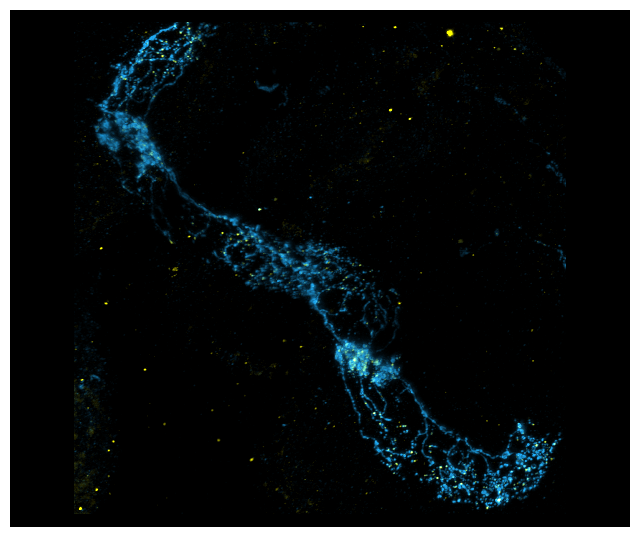

In [9]:
# "screenshot" of top view of 3D view (both channels):

with napari.gui_qt():
    viewer = napari.Viewer(ndisplay=3)

    viewer.add_image(
        red_channel,
        name='568 Channel',
        colormap='bop blue',
        blending='additive',
        contrast_limits=(200, 6000),
        rendering='attenuated_mip',
        attenuation=0.05,
    )
    viewer.add_image(
        green_channel,
        name='488 Channel',
        colormap='yellow',
        blending='additive',
        contrast_limits=(200, 1500),
        rendering='mip',
    )

    # 2) Grab a *4× larger* screenshot of just the 3D canvas:
    highres = viewer.screenshot(canvas_only=True, scale=4)

# 3) Embed in a Matplotlib fig and save:
fig, ax = plt.subplots(figsize=(8, 8))   # size in inches is arbitrary
ax.imshow(highres, interpolation='nearest')
ax.axis('off')

# push out the SVG/EPS with your giant bitmap inside:
fig.savefig('fly1_2channels.svg', format='svg',
            bbox_inches='tight', pad_inches=0, dpi=800)
#fig.savefig('napari_3d_ultrahighres.eps', format='eps', bbox_inches='tight', pad_inches=0, dpi=800)

/Users/fisherguest/miniconda3/envs/sansachen_czi/lib/python3.11/contextlib.py:137: FutureWarning: 
The 'gui_qt()' context manager is deprecated.
If you are running napari from a script, please use 'napari.run()' as follows:

    import napari

    viewer = napari.Viewer()  # no prior setup needed
    # other code using the viewer...
    napari.run()

In IPython or Jupyter, 'napari.run()' is not necessary. napari will automatically
start an interactive event loop for you: 

    import napari
    viewer = napari.Viewer()  # that's it!

  return next(self.gen)
/Users/fisherguest/miniconda3/envs/sansachen_czi/lib/python3.11/site-packages/napari/_qt/qt_event_loop.py:338: FutureWarning: `QApplication` instance access through `get_app` is deprecated and will be removed in 0.6.0.
Please use `get_qapp` instead.

  app = get_app()


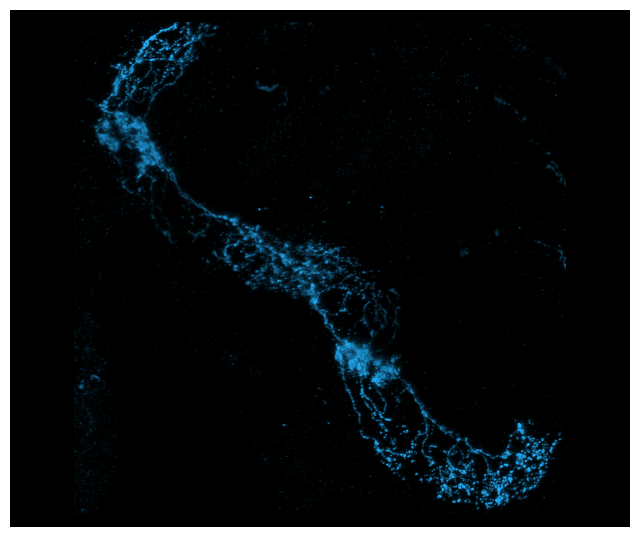

In [ ]:
# "screenshot" of top view of 3D view (red channel only):


with napari.gui_qt():
    viewer = napari.Viewer(ndisplay=3)

    viewer.add_image(
        red_channel,
        name='568 Channel',
        colormap='bop blue',
        blending='additive',
        contrast_limits=(200, 6000),
        rendering='attenuated_mip',
    )

    # 2) Grab a *4× larger* screenshot of just the 3D canvas:
    highres = viewer.screenshot(canvas_only=True, scale=4)

# 3) Embed in a Matplotlib fig and save:
fig, ax = plt.subplots(figsize=(8, 8))   # size in inches is arbitrary
ax.imshow(highres, interpolation='nearest')
ax.axis('off')

# push out the SVG/EPS with your giant bitmap inside:
fig.savefig('fly1_tdt.svg', format='svg',
            bbox_inches='tight', pad_inches=0, dpi=800)

/Users/fisherguest/miniconda3/envs/sansachen_czi/lib/python3.11/contextlib.py:137: FutureWarning: 
The 'gui_qt()' context manager is deprecated.
If you are running napari from a script, please use 'napari.run()' as follows:

    import napari

    viewer = napari.Viewer()  # no prior setup needed
    # other code using the viewer...
    napari.run()

In IPython or Jupyter, 'napari.run()' is not necessary. napari will automatically
start an interactive event loop for you: 

    import napari
    viewer = napari.Viewer()  # that's it!

  return next(self.gen)
/Users/fisherguest/miniconda3/envs/sansachen_czi/lib/python3.11/site-packages/napari/_qt/qt_event_loop.py:338: FutureWarning: `QApplication` instance access through `get_app` is deprecated and will be removed in 0.6.0.
Please use `get_qapp` instead.

  app = get_app()


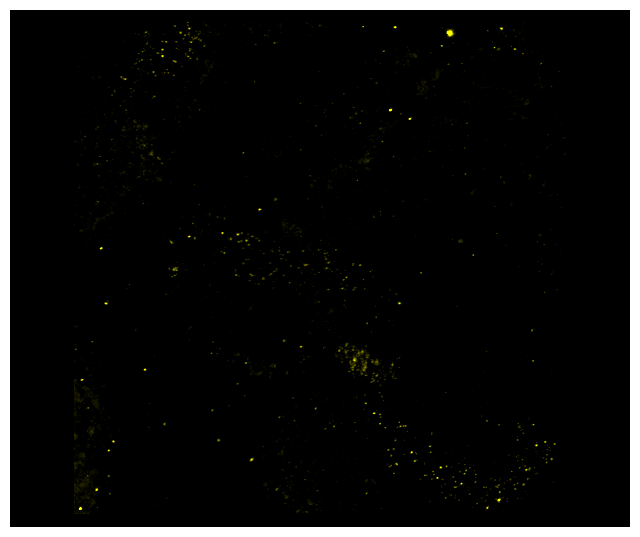

: 

In [ ]:
# "screenshot" of top view of 3D view (green channel only):


with napari.gui_qt():
    viewer = napari.Viewer(ndisplay=3)

    viewer.add_image(
        green_channel,
        name='488 Channel',
        colormap='yellow',
        blending='additive',
        contrast_limits=(200, 1500),
        rendering='mip',
    )

    # 2) Grab a *4× larger* screenshot of just the 3D canvas:
    highres = viewer.screenshot(canvas_only=True, scale=4)

# 3) Embed in a Matplotlib fig and save:
fig, ax = plt.subplots(figsize=(8, 8))   # size in inches is arbitrary
ax.imshow(highres, interpolation='nearest')
ax.axis('off')

# push out the SVG/EPS with your giant bitmap inside:
fig.savefig('fly1_gfp.svg', format='svg',
            bbox_inches='tight', pad_inches=0, dpi=800)

In [ ]:
# ---------------------------
# 1) Compute the projections
# ---------------------------

# --- Red channel: attenuated MIP ---
attenuation = 0.05  # same as napari’s default :contentReference[oaicite:0]{index=0}
# build per‐slice weights: deeper slices are dimmed exponentially
z = np.arange(red_channel.shape[0])
weights = np.exp(-attenuation * z)[:, None, None]  
# apply weights and take max
att_stack = red_channel * weights
mip_red = np.max(att_stack, axis=0)

# --- Green channel: standard MIP ---
mip_green = np.max(green_channel, axis=0)


# ----------------------------------
# 2) Normalize, threshold & gamma
# ----------------------------------

def normalize_and_gamma(img, vmin, vmax, gamma):
    # clip to [vmin, vmax], scale to [0,1], then apply gamma
    clipped = np.clip(img, vmin, vmax)
    normed  = (clipped - vmin) / (vmax - vmin)
    return normed ** (1.0 / gamma)

# your parameters
red_n = normalize_and_gamma(mip_red, 16,  97,  0.83)
grn_n = normalize_and_gamma(mip_green, 33, 135, 1.0)


# ----------------------------------
# 3) Color‐map each single‐channel
# ----------------------------------

h, w = red_n.shape
# red channel → “bop blue”  (you can substitute the hex code for bop-blue)
# here we map into the blue component
red_rgb = np.zeros((h, w, 3), dtype=float)
red_rgb[..., 2] = red_n  # B channel

# green channel → yellow  (R+G)
grn_rgb = np.zeros((h, w, 3), dtype=float)
grn_rgb[..., 0] = grn_n  # R
grn_rgb[..., 1] = grn_n  # G

# ----------------------------------
# 4) Composite with additive blending
# ----------------------------------

composite = red_rgb + grn_rgb
composite = np.clip(composite, 0, 1)


# ----------------------------------
# 5) Save as SVG or EPS
# ----------------------------------

fig, ax = plt.subplots(figsize=(w/100, h/100), dpi=100)
ax.imshow(composite, interpolation='nearest')
ax.axis('off')

# vector‐format export
fig.savefig('mip_composite.svg', format='svg', bbox_inches='tight', pad_inches=0)
fig.savefig('mip_composite.eps', format='eps', bbox_inches='tight', pad_inches=0)